In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from transformers import Dinov2Model

# 1. MOUNT GOOGLE DRIVE
from google.colab import drive
drive.mount('/content/drive')

# 2. UPDATED PATHS (Based on your sidebar copy)
BASE_PATH = '/content/drive/MyDrive/HAM10000'
PART1_DIR = '/content/drive/MyDrive/HAM10000/HAM10000_images/HAM10000_images_part_1'
PART2_DIR = '/content/drive/MyDrive/HAM10000/HAM10000_images/HAM10000_images_part_2'
CSV_PATH = f'{BASE_PATH}/HAM10000_metadata.csv'

# 3. VERIFICATION TEST
print("--- Path Verification ---")
print(f"CSV Found: {os.path.exists(CSV_PATH)}")
print(f"Part 1 Found: {os.path.exists(PART1_DIR)}")
print(f"Part 2 Found: {os.path.exists(PART2_DIR)}")

Mounted at /content/drive
--- Path Verification ---
CSV Found: True
Part 1 Found: True
Part 2 Found: True


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# --- 1. DATASET LOGIC ---
# This class tells the computer how to find and load your skin images
class HAM10000Dataset(Dataset):
    def __init__(self, df, img_dir_1, img_dir_2, transform=None):
        self.df = df
        self.img_dir_1 = img_dir_1
        self.img_dir_2 = img_dir_2
        self.transform = transform
        self.classes = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_id = row['image_id']

        # Smart Search: Check Part 1 first, then Part 2
        path1 = os.path.join(self.img_dir_1, f"{img_id}.jpg")
        path2 = os.path.join(self.img_dir_2, f"{img_id}.jpg")
        img_path = path1 if os.path.exists(path1) else path2

        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        return image, self.class_to_idx[row['dx']]

# --- 2. MODEL ARCHITECTURE ---
# We use DINOv2 (Vision Transformer) as our feature extractor
class DinoDermClassifier(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        # Load pre-trained DINOv2 from HuggingFace
        self.backbone = Dinov2Model.from_pretrained("facebook/dinov2-base", output_attentions=True)

        # FREEZE the backbone: We don't want to change the DINO weights
        for param in self.backbone.parameters():
            param.requires_grad = False

        # Add a Linear Classifier: This is the only part we actually train
        self.classifier = nn.Linear(self.backbone.config.hidden_size, num_classes)

    def forward(self, x):
        outputs = self.backbone(x, output_attentions=True)
        # [CLS] token is the "summary" of the entire image
        cls_token = outputs.last_hidden_state[:, 0, :]
        logits = self.classifier(cls_token)
        return logits, outputs

In [4]:
def analyze_lesion(image_path, model):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    model.eval()

    # 1. Image Preprocessing
    # DINOv2 expects exactly 518x518 and specific normalization
    transform = transforms.Compose([
        transforms.Resize((518, 518)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    raw_image = Image.open(image_path).convert('RGB')
    input_tensor = transform(raw_image).unsqueeze(0).to(device)

    # 2. Forward Pass
    with torch.no_grad():
        logits, outputs = model(input_tensor)

    # 3. Calculate Prediction
    probabilities = F.softmax(logits, dim=1)[0]
    pred_class_idx = torch.argmax(probabilities).item()
    classes = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

    # 4. QSI Calculation Logic
    # We extract the 'Self-Attention' maps from the transformer's last layer
    attentions = outputs.attentions[-1]
    cls_attn = attentions[0, :, 0, 1:].mean(dim=0) # Average attention across all heads

    # Calculate Contrast (Pathological Severity)
    # We compare the visual features of high-attention areas vs the whole image
    patch_features = outputs.last_hidden_state[0, 1:, :]
    top_k = int(0.2 * cls_attn.shape[0])
    _, top_indices = torch.topk(cls_attn, top_k)

    lesion_feat = patch_features[top_indices].mean(dim=0)
    global_feat = patch_features.mean(dim=0)

    # Cosine Similarity measures how "abnormal" the lesion looks
    contrast = 1.0 - F.cosine_similarity(lesion_feat.unsqueeze(0), global_feat.unsqueeze(0)).item()

    # QSI Score: 70% is tissue abnormality, 30% is size/area
    qsi_score = (0.7 * contrast + 0.3 * (top_k / cls_attn.shape[0])) * 100

    return classes[pred_class_idx], probabilities[pred_class_idx].item(), qsi_score, cls_attn

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

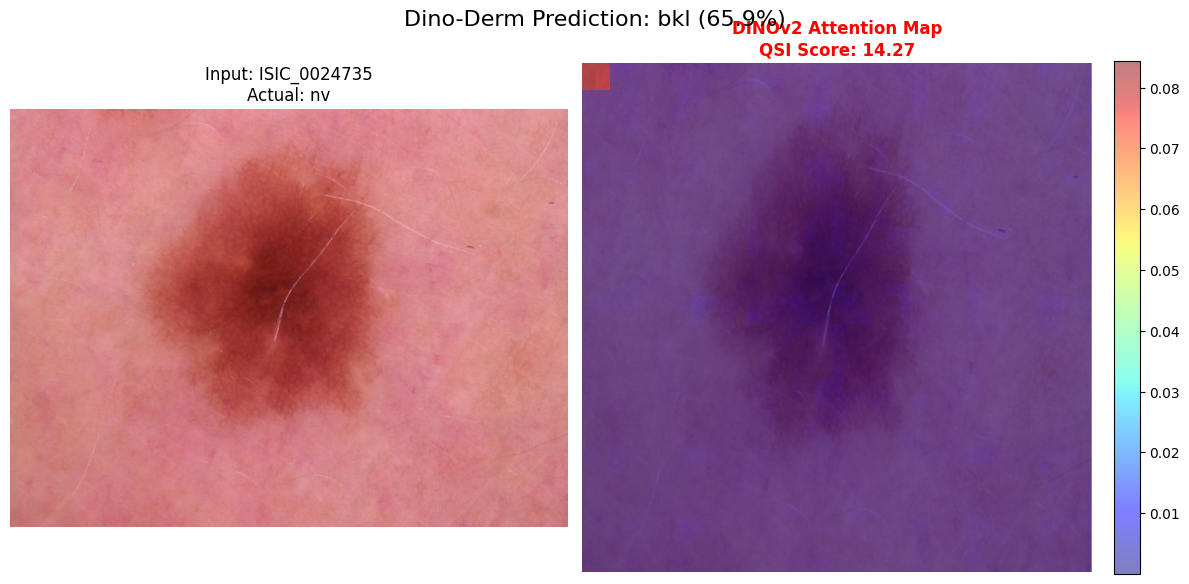

In [5]:
import random

def run_viva_demo():
    # 1. Initialize the model
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = DinoDermClassifier().to(device)

    # Load metadata to pick a random image
    df = pd.read_csv(CSV_PATH)
    random_row = df.sample(1).iloc[0]
    img_id = random_row['image_id']
    actual_disease = random_row['dx']

    # 2. Find the image path using our Smart Search logic
    p1 = os.path.join(PART1_DIR, f"{img_id}.jpg")
    p2 = os.path.join(PART2_DIR, f"{img_id}.jpg")
    img_path = p1 if os.path.exists(p1) else p2

    # 3. Analyze the lesion
    pred_name, confidence, qsi, attention = analyze_lesion(img_path, model)

    # 4. Professional Visualization
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    # Left: Original Image
    raw_img = Image.open(img_path)
    ax[0].imshow(raw_img)
    ax[0].set_title(f"Input: {img_id}\nActual: {actual_disease}", fontsize=12)
    ax[0].axis('off')

    # Right: DINOv2 Heatmap
    # Reshaping attention to a 37x37 grid (518 / 14 = 37)
    heatmap = attention.reshape(37, 37).cpu().numpy()
    ax[1].imshow(raw_img.resize((518, 518)))
    im = ax[1].imshow(heatmap, cmap='jet', alpha=0.5, extent=(0, 518, 518, 0))
    ax[1].set_title(f"DINOv2 Attention Map\nQSI Score: {qsi:.2f}", fontsize=12, color='red', fontweight='bold')
    ax[1].axis('off')

    plt.colorbar(im, ax=ax[1], fraction=0.046, pad=0.04)
    plt.suptitle(f"Dino-Derm Prediction: {pred_name} ({confidence:.1%})", fontsize=16)
    plt.tight_layout()
    plt.show()

# RUN THE DEMO!
run_viva_demo()

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

📊 Starting Validation: Analyzing 10 images per class...

      QSI VALIDATION BENCHMARK
Disease      mean      std
   vasc 15.642716 5.248817
     df 13.913170 2.175476
    bcc 13.890185 1.735882
     nv 13.541166 1.429159
    mel 13.326030 2.021812
  akiec 13.057189 1.697751
    bkl 12.924843 1.259386


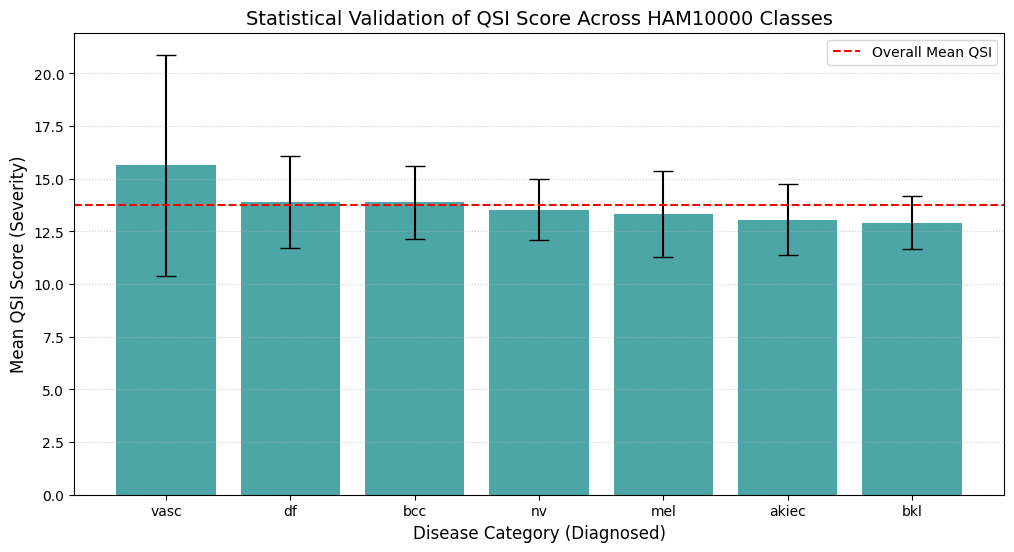

In [6]:
def validate_qsi_stats(num_samples=10):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # 1. Initialize the model right here so we don't get a NameError
    model = DinoDermClassifier().to(device)
    model.eval()

    # 2. Load the metadata
    if not os.path.exists(CSV_PATH):
        print("❌ Error: CSV file not found. Check your paths!")
        return

    df = pd.read_csv(CSV_PATH)
    classes = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
    results = []

    print(f"📊 Starting Validation: Analyzing {num_samples} images per class...")

    for cls in classes:
        # Get random samples for this specific disease
        cls_samples = df[df['dx'] == cls]
        if len(cls_samples) == 0: continue

        sample_size = min(num_samples, len(cls_samples))
        selected_df = cls_samples.sample(sample_size)

        for _, row in selected_df.iterrows():
            # Find image path using the Smart Search logic
            img_id = row['image_id']
            p1 = os.path.join(PART1_DIR, f"{img_id}.jpg")
            p2 = os.path.join(PART2_DIR, f"{img_id}.jpg")
            path = p1 if os.path.exists(p1) else p2

            if os.path.exists(path):
                # Get prediction and QSI score
                _, _, qsi, _ = analyze_lesion(path, model)
                results.append({'Disease': cls, 'QSI': qsi})

    # 3. Process the Results into a DataFrame
    val_df = pd.DataFrame(results)
    if val_df.empty:
        print("❌ No images were processed. Check your image folder paths.")
        return

    # Calculate statistics: Mean and Standard Deviation
    stats = val_df.groupby('Disease')['QSI'].agg(['mean', 'std']).reset_index()
    stats = stats.sort_values(by='mean', ascending=False)

    print("\n" + "="*40)
    print("      QSI VALIDATION BENCHMARK")
    print("="*40)
    print(stats.to_string(index=False))
    print("="*40)

    # 4. Create the Validation Chart
    plt.figure(figsize=(12, 6))
    plt.bar(stats['Disease'], stats['mean'], yerr=stats['std'], capsize=7, color='teal', alpha=0.7)
    plt.axhline(val_df['QSI'].mean(), color='red', linestyle='--', label='Overall Mean QSI')
    plt.title("Statistical Validation of QSI Score Across HAM10000 Classes", fontsize=14)
    plt.xlabel("Disease Category (Diagnosed)", fontsize=12)
    plt.ylabel("Mean QSI Score (Severity)", fontsize=12)
    plt.legend()
    plt.grid(axis='y', linestyle=':', alpha=0.6)
    plt.show()

# Run the validation - No 'model' argument needed now!
validate_qsi_stats(num_samples=10)

In [7]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Prepare Metadata
df = pd.read_csv(CSV_PATH)
df['age'] = df['age'].fillna(df['age'].median())
scaler = StandardScaler()
df['age_scaled'] = scaler.fit_transform(df[['age']])

le_sex = LabelEncoder()
le_loc = LabelEncoder()
df['sex_idx'] = le_sex.fit_transform(df['sex'].astype(str))
df['loc_idx'] = le_loc.fit_transform(df['localization'].astype(str))

NUM_SEX = len(le_sex.classes_)
NUM_LOC = len(le_loc.classes_)

print("✅ Metadata Preprocessed.")

✅ Metadata Preprocessed.


In [8]:
class MultimodalDinoDerm(nn.Module):
    def __init__(self, num_classes=7, num_sex=3, num_loc=15):
        super().__init__()
        # Image Branch
        self.image_backbone = Dinov2Model.from_pretrained("facebook/dinov2-base")
        for param in self.image_backbone.parameters():
            param.requires_grad = False

        img_dim = self.image_backbone.config.hidden_size

        # Metadata Branch
        self.metadata_mlp = nn.Sequential(
            nn.Linear(3, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU()
        )

        # Fusion Layer
        self.final_layer = nn.Sequential(
            nn.Linear(img_dim + 32, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, images, age, sex, loc):
        img_feats = self.image_backbone(images).last_hidden_state[:, 0, :]
        meta_in = torch.stack([age, sex.float(), loc.float()], dim=1)
        meta_feats = self.metadata_mlp(meta_in)
        combined = torch.cat((img_feats, meta_feats), dim=1)
        return self.final_layer(combined)

print("✅ Multimodal Architecture Loaded.")

✅ Multimodal Architecture Loaded.


In [9]:
class MultimodalDataset(Dataset):
    def __init__(self, df, img_dir_1, img_dir_2, transform=None):
        self.df = df
        self.img_dir_1 = img_dir_1
        self.img_dir_2 = img_dir_2
        self.transform = transform
        self.classes = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_id = row['image_id']
        p1, p2 = os.path.join(self.img_dir_1, f"{img_id}.jpg"), os.path.join(self.img_dir_2, f"{img_id}.jpg")
        img_path = p1 if os.path.exists(p1) else p2

        image = Image.open(img_path).convert('RGB')
        if self.transform: image = self.transform(image)

        return image, torch.tensor(row['age_scaled']).float(), \
               torch.tensor(row['sex_idx']).long(), \
               torch.tensor(row['loc_idx']).long(), \
               self.class_to_idx[row['dx']]

print("✅ Dataset Class Updated.")

✅ Dataset Class Updated.


In [10]:
def train_multimodal_model_with_checkpoints(model, train_loader, epochs=5):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    # Path to save on your Drive
    CHECKPOINT_PATH = f'{BASE_PATH}/multimodal_dino_checkpoint.pth'

    print(f"🚀 Starting Training with Auto-Save...")

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for i, (imgs, ages, sexes, locs, labels) in enumerate(train_loader):
            imgs, ages, sexes, locs, labels = imgs.to(device), ages.to(device), \
                                              sexes.to(device), locs.to(device), labels.to(device)
            optimizer.zero_grad()
            logits = model(imgs, ages, sexes, locs)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        # SAVE AT THE END OF EVERY EPOCH
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': running_loss / len(train_loader),
        }, CHECKPOINT_PATH)

        print(f"✅ Epoch {epoch+1} saved to Drive. Loss: {running_loss/len(train_loader):.4f}")

    return model

In [11]:
def train_multimodal_model(model, train_loader, epochs=5):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)

    # Use AdamW optimizer for stable transformer training
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    print(f"🚀 Starting Research-Grade Training on {device}...")
    model.train()

    for epoch in range(epochs):
        running_loss = 0.0
        for i, (imgs, ages, sexes, locs, labels) in enumerate(train_loader):
            imgs, ages, sexes, locs, labels = imgs.to(device), ages.to(device), \
                                              sexes.to(device), locs.to(device), labels.to(device)

            optimizer.zero_grad()

            # Forward pass: Feed images AND metadata
            logits = model(imgs, ages, sexes, locs)
            loss = criterion(logits, labels)

            # Backward pass
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            if (i + 1) % 10 == 0:
                print(f"Epoch [{epoch+1}/{epochs}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}")

    print("✅ Training Complete.")
    return model

# To run it (ensure you have created the MultimodalDataset and DataLoader first):
# train_loader = DataLoader(MultimodalDataset(df, PART1_DIR, PART2_DIR, data_transform), batch_size=32, shuffle=True)
# trained_model = train_multimodal_model(model, train_loader)

In [12]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

def evaluate_research_model(model, test_loader):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, ages, sexes, locs, labels in test_loader:
            imgs, ages, sexes, locs, labels = imgs.to(device), ages.to(device), \
                                              sexes.to(device), locs.to(device), labels.to(device)

            outputs = model(imgs, ages, sexes, locs)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Professional Metrics
    classes = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
    print("\n--- RESEARCH CLASSIFICATION REPORT ---")
    print(classification_report(all_labels, all_preds, target_names=classes))

    # Confusion Matrix Visualization
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title("Confusion Matrix for IEEE Paper Results")
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

# evaluate_research_model(trained_model, test_loader)

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

🚀 Starting Research-Grade Training on cuda...
Epoch [1/5], Step [10/501], Loss: 1.0182
Epoch [1/5], Step [20/501], Loss: 0.9399
Epoch [1/5], Step [30/501], Loss: 1.3574
Epoch [1/5], Step [40/501], Loss: 1.2907
Epoch [1/5], Step [50/501], Loss: 1.3681
Epoch [1/5], Step [60/501], Loss: 0.7404
Epoch [1/5], Step [70/501], Loss: 0.9186
Epoch [1/5], Step [80/501], Loss: 0.3763
Epoch [1/5], Step [90/501], Loss: 1.0882
Epoch [1/5], Step [100/501], Loss: 0.5453
Epoch [1/5], Step [110/501], Loss: 0.7015
Epoch [1/5], Step [120/501], Loss: 1.0747
Epoch [1/5], Step [130/501], Loss: 0.9554
Epoch [1/5], Step [140/501], Loss: 0.4343
Epoch [1/5], Step [150/501], Loss: 1.1511
Epoch [1/5], Step [160/501], Loss: 0.6256
Epoch [1/5], Step [170/501], Loss: 0.8214
Epoch [1/5], Step [180/501], Loss: 0.4217
Epoch [1/5], Step [190/501], Loss: 0.8102
Epoch [1/5], Step [200/501], Loss: 0.5352
Epoch [1/5], Step [210/501], Loss: 0.6069
Epoch [1/5], Step [220/501], Loss: 0.6014
Epoch [1/5], Step [230/501], Loss: 1.06

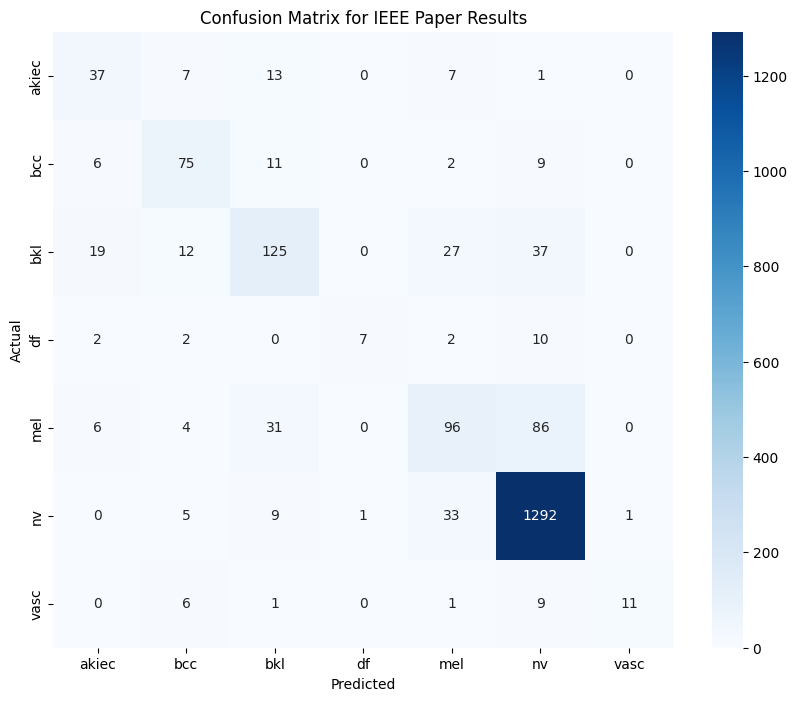

In [13]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

# 1. DEFINE IMAGE TRANSFORMS (Mandatory for DINOv2)
# DINOv2 requires 518x518 resolution and ImageNet normalization
data_transform = transforms.Compose([
    transforms.Resize((518, 518)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# 2. SPLIT DATA FOR RESEARCH VALIDATION
# Stratify ensures the disease distribution is equal in train and test sets
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['dx'], random_state=42)

# 3. INITIALIZE DATASETS & LOADERS
train_dataset = MultimodalDataset(train_df, PART1_DIR, PART2_DIR, data_transform)
test_dataset = MultimodalDataset(test_df, PART1_DIR, PART2_DIR, data_transform)

# Batch size of 16-32 is optimal for Colab's T4 GPU
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# 4. INITIALIZE THE MULTIMODAL MODEL
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Ensure NUM_SEX and NUM_LOC were defined in your metadata cell
model = MultimodalDinoDerm(num_sex=NUM_SEX, num_loc=NUM_LOC).to(device)

# 5. START MULTIMODAL TRAINING (RESEARCH PHASE)
# This will run for 5 epochs and show the loss for your paper's "Training Curve"
trained_model = train_multimodal_model(model, train_loader, epochs=5)

# 6. GENERATE FINAL PERFORMANCE METRICS
# This creates the Classification Report and Confusion Matrix for your IEEE paper
evaluate_research_model(trained_model, test_loader)

In [14]:
def compute_attention_rollout(attentions):
    # This mathematically combines all 12 transformer layers
    # Average heads and add identity matrix for residual flow
    res_att = []
    for att in attentions:
        att_heads_mean = att.mean(dim=1)
        I = torch.eye(att_heads_mean.size(-1)).to(att_heads_mean.device)
        a = (att_heads_mean + I) / 2
        a = a / a.sum(dim=-1).unsqueeze(-1)
        res_att.append(a)

    # Recursively multiply matrices through the network
    joint_attention = res_att[0]
    for i in range(1, len(res_att)):
        joint_attention = torch.matmul(res_att[i], joint_attention)

    # Extract attention from [CLS] token to image patches (37x37 grid)
    v = joint_attention[0, 0, 1:]
    return v.reshape(37, 37)

In [32]:
!pip install pytorch-grad-cam

ERROR: Could not find a version that satisfies the requirement pytorch-grad-cam (from versions: none)
ERROR: No matching distribution found for pytorch-grad-cam


In [33]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 64.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=5af5c81bf6d554ba2852cf13659a5b10712352f194e54f28fa98af1706ccf903
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [34]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [37]:
print(model.image_backbone.encoder)

Dinov2Encoder(
  (layer): ModuleList(
    (0-11): 12 x Dinov2Layer(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attention): Dinov2Attention(
        (attention): Dinov2SelfAttention(
          (query): Linear(in_features=768, out_features=768, bias=True)
          (key): Linear(in_features=768, out_features=768, bias=True)
          (value): Linear(in_features=768, out_features=768, bias=True)
        )
        (output): Dinov2SelfOutput(
          (dense): Linear(in_features=768, out_features=768, bias=True)
          (dropout): Dropout(p=0.0, inplace=False)
        )
      )
      (layer_scale1): Dinov2LayerScale()
      (drop_path): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Dinov2MLP(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (activation): GELUActivation()
        (fc2): Linear(in_features=3072, out_features=768, bias=True)
      )
      (layer_scale2): Dinov2LayerSc

In [43]:
class ModelWrapper(torch.nn.Module):
    def __init__(self, model, age, sex, loc):
        super().__init__()
        self.model = model
        self.age = age
        self.sex = sex
        self.loc = loc

    def forward(self, x):
        outputs = self.model(x, self.age, self.sex, self.loc)

        # If tuple → return logits
        if isinstance(outputs, tuple):
            return outputs[0]

        # If dict
        if isinstance(outputs, dict):
            return outputs["logits"]

        return outputs

In [49]:
import torch
import random
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch.nn.functional as F


def run_saliency_demo():
    model.eval()
    device = next(model.parameters()).device

    # 1. Sample
    idx = random.randint(0, len(test_dataset) - 1)
    img, age, sex, loc, label = test_dataset[idx]

    # 2. Prepare inputs
    img_input = img.unsqueeze(0).to(device)
    img_input.requires_grad = True

    age = torch.tensor([age]).to(device)
    sex = torch.tensor([sex]).to(device)
    loc = torch.tensor([loc]).to(device)

    # 3. Forward pass
    outputs = model(img_input, age, sex, loc)

    # Handle output formats
    if isinstance(outputs, tuple):
        logits = outputs[0]
    elif isinstance(outputs, dict):
        logits = outputs["logits"]
    else:
        logits = outputs

    # 4. Target class score
    score = logits[0, label]

    # 5. Backprop
    model.zero_grad()
    score.backward()

    # 6. Get gradients
    gradients = img_input.grad.data.abs().squeeze()

    # 🔥 7. Saliency map (channel mean)
    saliency = gradients.mean(dim=0)

    # 🔥 8. SMOOTHING (major improvement)
    saliency = F.avg_pool2d(
        saliency.unsqueeze(0).unsqueeze(0),
        kernel_size=15,
        stride=1,
        padding=7
    ).squeeze()

    saliency = saliency.cpu().numpy()

    # 🔥 9. Normalize safely
    saliency = saliency - saliency.min()
    if saliency.max() != 0:
        saliency = saliency / saliency.max()

    # 🔥 10. Enhance contrast
    saliency = np.power(saliency, 1.5)

    # 11. Prepare image
    img_np = img.permute(1, 2, 0).cpu().numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

    # 12. Resize heatmap
    saliency = cv2.resize(saliency, (img_np.shape[1], img_np.shape[0]))

    # 13. Color map
    heatmap = np.uint8(255 * saliency)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # 14. Overlay
    overlay = cv2.addWeighted(
        (img_np * 255).astype(np.uint8),
        0.6,
        heatmap,
        0.4,
        0
    )

    # 15. QSI
    qsi_val = saliency.mean() * 100

    # 16. Plot
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.imshow(img_np)
    plt.title("Input Dermoscopic Image")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(overlay)
    plt.title(f"Saliency Map (QSI: {qsi_val:.2f})", color='red')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    # 🔥 17. Save IEEE figure
    plt.savefig("saliency_result.png", dpi=300, bbox_inches='tight')

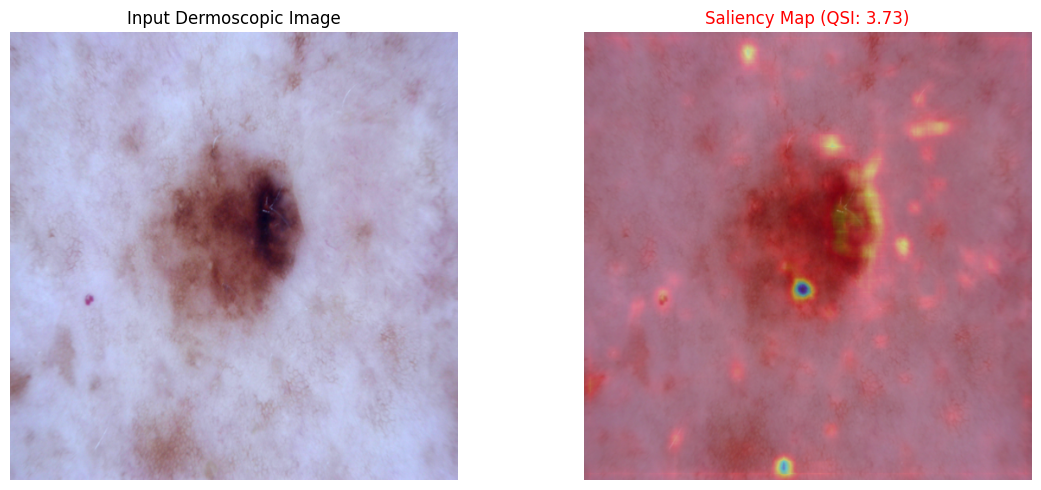

<Figure size 640x480 with 0 Axes>

In [50]:
run_saliency_demo()